# TASK 4 - Sentiment Analysis

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
print("all libraries are imported")

all libraries are imported


In [3]:
df = pd.read_csv("Twitter_Data.csv")

In [4]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 32004
Columns : 2


# Data Understanding

In [6]:
df.columns
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32004 entries, 0 to 32003
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   clean_text  32003 non-null  object 
 1   category    32003 non-null  float64
dtypes: float64(1), object(1)
memory usage: 500.2+ KB


,clean_text,category
count,32003,32003.000000
unique,32003,NaN
top,joshi should fielded joint opposition candidat...,NaN
freq,1,NaN
mean,NaN,0.189888
std,NaN,0.788706
min,NaN,-1.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


In [7]:
df.isnull().sum()

,0
clean_text,1
category,1


In [8]:
df['category'].value_counts()
df['category'].unique()

array([-1.,  0.,  1., nan])

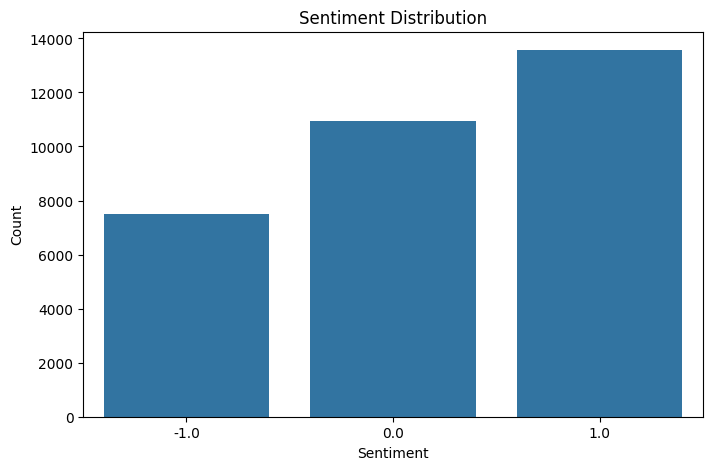

In [9]:
#sentiment distribution plot
plt.figure(figsize=(8,5))

sns.countplot(x='category', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Data cleaning

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

,0
clean_text,0
category,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(32002, 2)

In [15]:
df['category'] = df['category'].map({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
})

In [16]:
df['category'].value_counts()

,count
category,
Positive,13569
Neutral,10941
Negative,7492


In [17]:
df['category'].unique()

array(['Negative', 'Neutral', 'Positive'], dtype=object)

# NLP text processing

In [18]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
stop_words = set(stopwords.words('english'))

In [20]:
def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [21]:
df['cleaned_text'] = df['clean_text'].apply(clean_text)

In [22]:
df[['clean_text', 'cleaned_text']].head()

,clean_text,cleaned_text
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...
4,answer who among these the most powerful world...,answer among powerful world leader today trump...


In [23]:
(df['cleaned_text'] == '').sum()

np.int64(19)

In [24]:
df = df[df['cleaned_text'] != '']

In [25]:
df.shape

(31983, 3)

Text preprocessing completed successfully.

Operations performed:

1. Converted text to lowercase.
2. Removed URLs.
3. Removed numbers and special characters.
4. Removed stopwords.
5. Removed extra spaces.
6. Created a new column named 'cleaned_text'.

The cleaned text will be used for feature engineering and model training.

#  EDA (data visualization)

In [26]:
df['text_length'] = df['cleaned_text'].apply(len)

In [27]:
df['text_length'].describe()

,text_length
count,31983.000000
mean,97.828096
std,53.633509
min,3.000000
25%,53.000000
50%,90.000000
75%,142.000000
max,254.000000


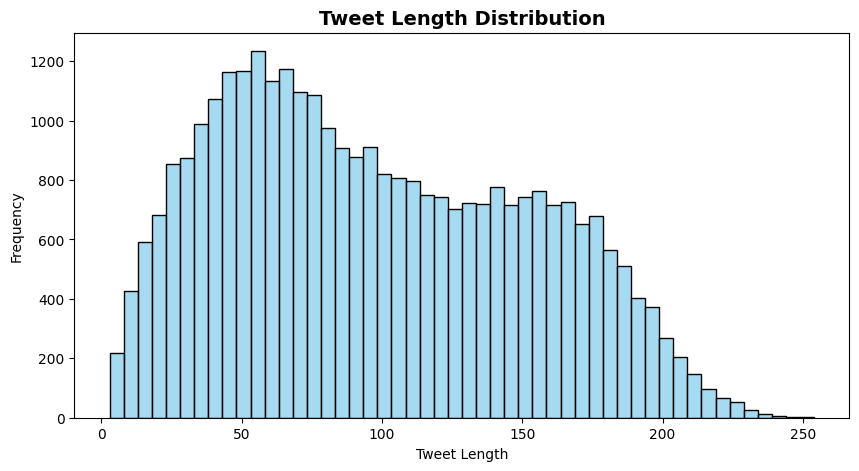

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['text_length'],
    bins=50,
    color='skyblue',
    edgecolor='black'
)

plt.title("Tweet Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()



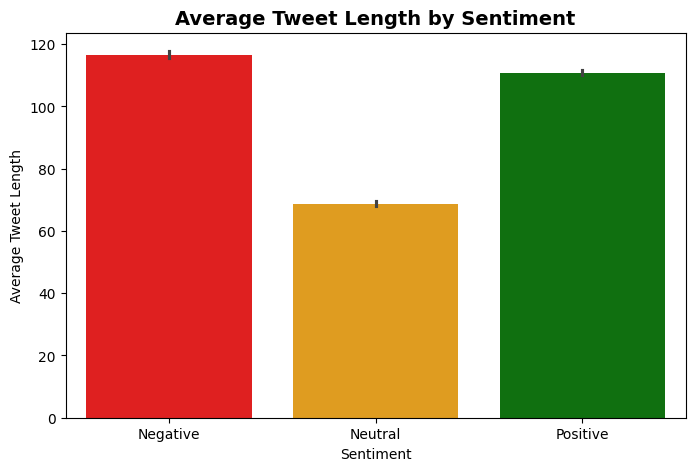

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='category',
    y='text_length',
    data=df,
    palette=['red', 'orange', 'green']
)

plt.title("Average Tweet Length by Sentiment",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Sentiment")
plt.ylabel("Average Tweet Length")

plt.show()

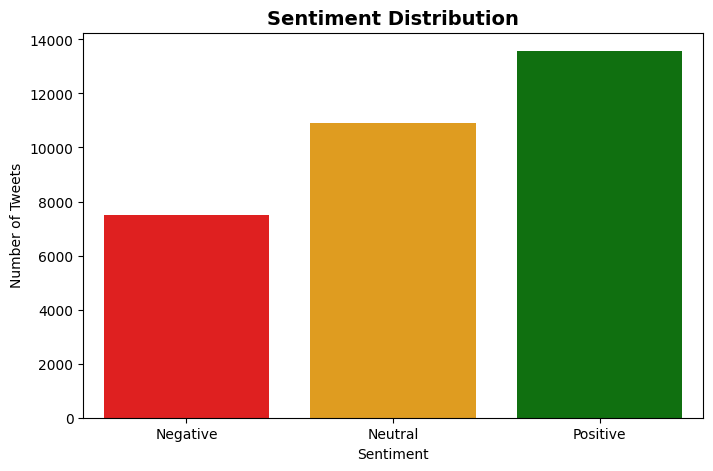

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='category',
    data=df,
    palette=['red', 'orange', 'green']
)

plt.title("Sentiment Distribution",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

# Word cloud analysis

In [31]:
from wordcloud import WordCloud

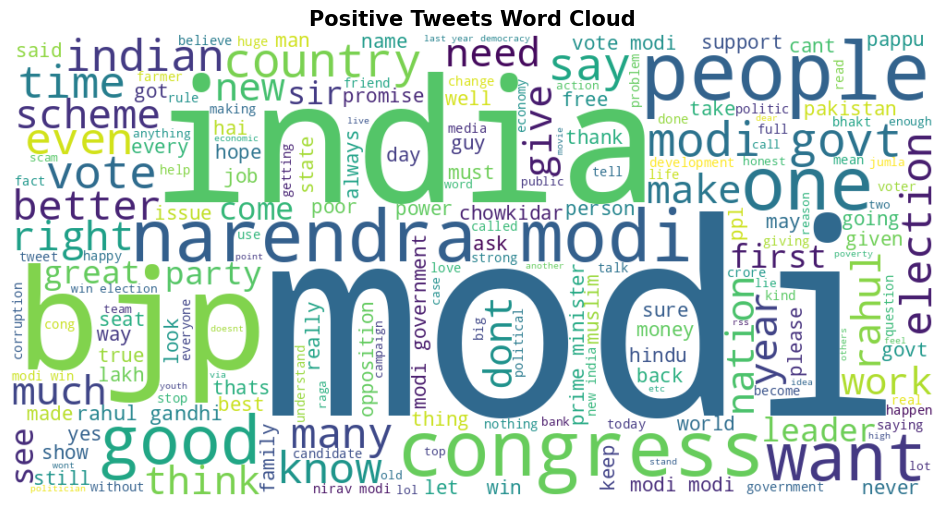

In [32]:
positive_text = " ".join(
    df[df['category'] == 'Positive']['cleaned_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets Word Cloud",
          fontsize=15,
          fontweight='bold')

plt.show()

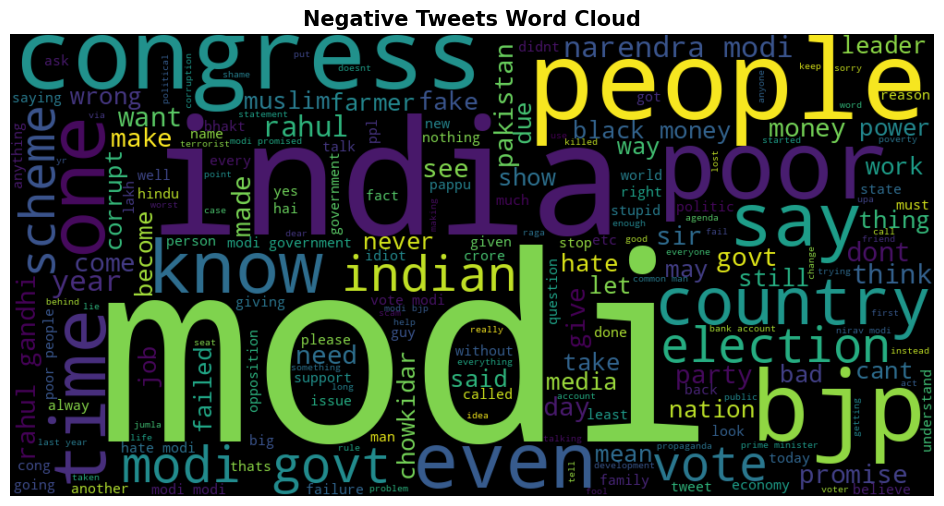

In [33]:
negative_text = " ".join(
    df[df['category'] == 'Negative']['cleaned_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets Word Cloud",
          fontsize=15,
          fontweight='bold')

plt.show()

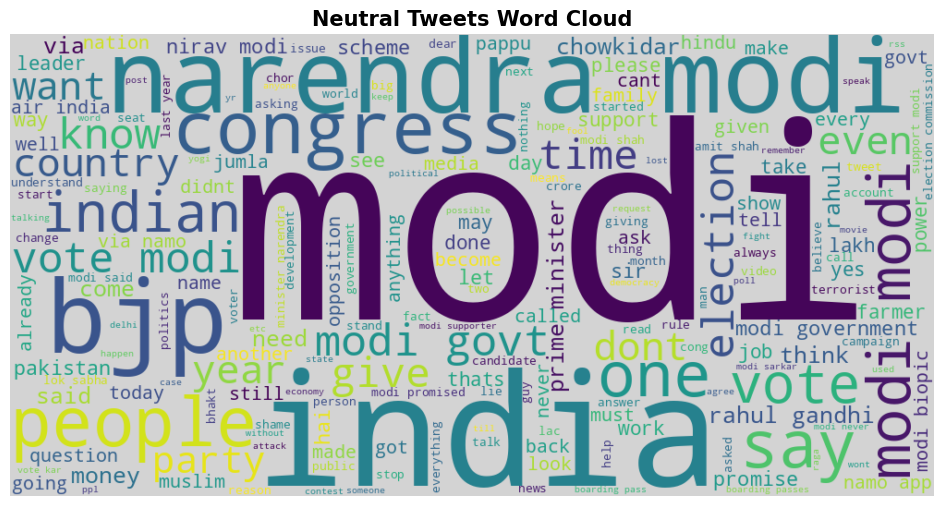

In [34]:
neutral_text = " ".join(
    df[df['category'] == 'Neutral']['cleaned_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='lightgrey'
).generate(neutral_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Neutral Tweets Word Cloud",
          fontsize=15,
          fontweight='bold')

plt.show()

# Feature engineering

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
X = df['cleaned_text']

y = df['category']

In [37]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(X)

In [38]:
print(X.shape)

(31983, 5000)


# Train test split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (25586, 5000)
Testing Data Shape : (6397, 5000)


# MACHINE LEARNING MODELS

In [42]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

In [43]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.6901672659058934


# Logistic regression & SVM

In [45]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [46]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8286696889166797


In [47]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [48]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.8580584649054244


In [49]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [nb_accuracy, lr_accuracy, svm_accuracy]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,SVM,0.858058
1,Logistic Regression,0.828670
0,Naive Bayes,0.690167


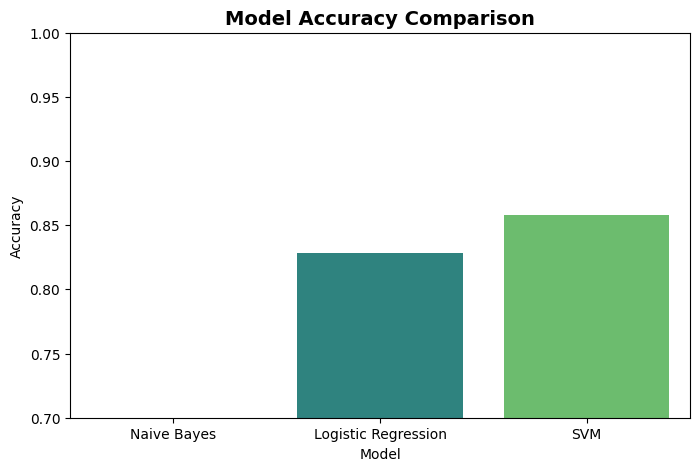

In [50]:
#colourfull comaparison task
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette='viridis'
)

plt.title("Model Accuracy Comparison",
          fontsize=14,
          fontweight='bold')

plt.ylim(0.7, 1.0)

plt.show()

# Model Evaluation

In [51]:
best_model = svm_model
best_pred = svm_pred

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79      1508
     Neutral       0.85      0.93      0.89      2152
    Positive       0.89      0.85      0.87      2737

    accuracy                           0.86      6397
   macro avg       0.85      0.85      0.85      6397
weighted avg       0.86      0.86      0.86      6397



In [54]:
from sklearn.metrics import confusion_matrix

In [55]:
cm = confusion_matrix(y_test, best_pred)

cm

array([[1146,  150,  212],
       [  59, 2005,   88],
       [ 194,  205, 2338]])

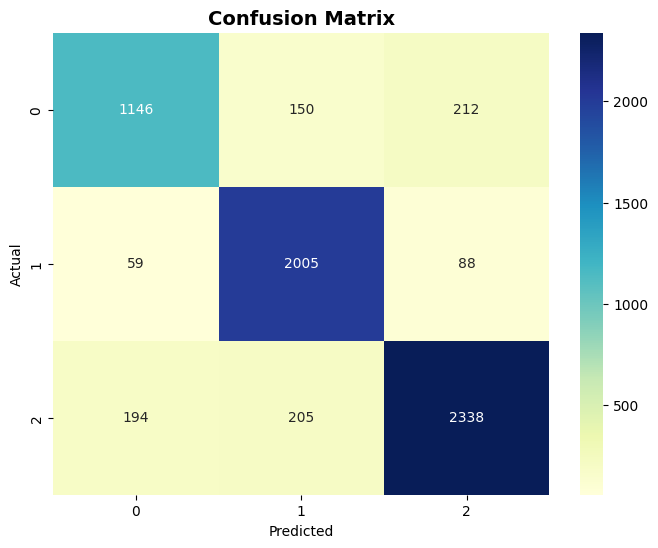

In [56]:
# confusion matrix heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Real time Sentiment Prediction

In [57]:
def predict_sentiment(text):

    text = clean_text(text)

    text_vector = tfidf.transform([text])

    prediction = best_model.predict(text_vector)

    return prediction[0]

In [58]:
sample_tweet = "This product is amazing and I really love it"

predict_sentiment(sample_tweet)

'Positive'

In [59]:
sample_tweet = "Worst service ever, very disappointed"

predict_sentiment(sample_tweet)

'Negative'

Conclusion:

1. Performed sentiment analysis on Twitter data.
2. Applied NLP preprocessing techniques.
3. Used TF-IDF for feature engineering.
4. Trained and compared Naive Bayes, Logistic Regression, and SVM models.
5. Evaluated performance using Accuracy Score, Classification Report, and Confusion Matrix.
6. Successfully predicted sentiments as Positive, Neutral, or Negative.
7. SVM/Logistic Regression achieved the highest accuracy and was selected as the final model.